# Citi Bike Analyse & Voorspellingen
**Gemaakt door:** Dimi

In dit notebook ga ik aan de slag met de tweede dataset van het project: de NYC Citi Bike trip data. Omdat deze bestanden gigantisch zijn, heb ik een scriptje geschreven dat de zip-files direct van de Amazon S3 bucket plukt. Daarna doe ik de data cleaning, bedenk ik een hypothese en train ik een paar vette Machine Learning modellen om te voorspellen wat voor soort fietser er op de fiets zit.

## 1. Data Automatisch Binnenhalen (Scraping)
De docent zei expliciet dat we dit niet handmatig mochten doen. Dus hier is de code om de data van begin 2023 te downloaden, uit te pakken en samen te voegen.

In [16]:
import urllib.request
import zipfile
import os
import pandas as pd
import glob
import numpy as np

# Ik pak even 2 maanden om het werkbaar te houden op mijn laptop
base_url = "https://s3.amazonaws.com/tripdata/"
files_to_download = [
    "202401-citibike-tripdata.zip",
    "202402-citibike-tripdata.zip"
]

data_dir = "data"
os.makedirs(data_dir, exist_ok=True)

for file in files_to_download:
    file_path = os.path.join(data_dir, file)
    if not os.path.exists(file_path):
        print(f"Bezig met downloaden van {file}...")
        urllib.request.urlretrieve(base_url + file, file_path)
        print("Download klaar, nu uitpakken...")
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)

# CSVs zoeken en inladen
csv_files = glob.glob(f"{data_dir}/*.csv")
df_list = [pd.read_csv(csv, low_memory=False) for csv in csv_files]
df = pd.concat(df_list, ignore_index=True)

print(f"\nYes, data is binnen! Totaal aantal ritten: {len(df)}")
display(df.head())


Yes, data is binnen! Totaal aantal ritten: 4009586


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,8E865410DBDE0CA9,electric_bike,2024-01-01 13:00:04.563,2024-01-01 13:04:04.652,3 St & 3 Ave,4028.03,Carroll St & Smith St,4225.14,40.675070,-73.987752,40.680611,-73.994758,casual
1,0403D0B3FC9CA77D,electric_bike,2024-01-08 19:36:43.520,2024-01-08 19:53:16.266,Franklin Ave & St Marks Ave,4107.05,Bedford Ave & Bergen St,4066.15,40.675832,-73.956168,40.676368,-73.952918,casual
2,F6DE7BB42FF550BE,electric_bike,2024-01-12 15:00:41.580,2024-01-12 15:36:29.622,W 67 St & Broadway,7116.04,Central Park W & W 103 St,7577.27,40.774925,-73.982666,40.795590,-73.961884,casual
3,84A995BFD98030D4,classic_bike,2024-01-12 16:52:19.025,2024-01-12 17:17:29.773,Central Park West & W 68 St,7079.06,E 5 St & Ave C,5545.04,40.773407,-73.977825,40.722992,-73.979955,member
4,7BBEAD4F2B535813,electric_bike,2024-01-05 19:50:19.202,2024-01-05 20:34:42.517,W 67 St & Broadway,7116.04,Ave A & E 14 St,5779.11,40.774925,-73.982666,40.730311,-73.980472,member


## 2. Data Cleaning & Feature Engineering
De rauwe data is best oké, maar ik mis wat handige features. Ik ga de start- en eindtijd omzetten naar een echte ritduur in minuten. Ook ga ik proberen de afstand (vogelvlucht) tussen start en eind te berekenen als de coördinaten (lat/lng) erin zitten.

In [17]:
# Datetimes parsen
df['started_at'] = pd.to_datetime(df['started_at'])
df['ended_at'] = pd.to_datetime(df['ended_at'])

# Ritduur berekenen
df['trip_duration_mins'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60.0

# Gekke uitschieters eruit gooien (negatieve ritten of ritten die 24+ uur duren = vergeten in te loggen)
df_clean = df[(df['trip_duration_mins'] > 1) & (df['trip_duration_mins'] < 180)].copy()

# Tijd-features toevoegen voor mijn aggregaties straks
df_clean['hour'] = df_clean['started_at'].dt.hour
df_clean['day_of_week'] = df_clean['started_at'].dt.dayofweek # 0=Maandag
df_clean['is_weekend'] = df_clean['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Feature engineering: Haversine afstand (als er GPS data is)
if 'start_lat' in df_clean.columns and 'end_lat' in df_clean.columns:
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371 # Radius van de aarde in km
        dlat = np.radians(lat2 - lat1)
        dlon = np.radians(lon2 - lon1)
        a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
        return R * c
    
    df_clean['distance_km'] = haversine(df_clean['start_lat'], df_clean['start_lng'], df_clean['end_lat'], df_clean['end_lng'])
    # Verwijder trips met missende afstanden
    df_clean = df_clean.dropna(subset=['distance_km'])

print(f"Data is opgeschoond! Rijen over: {len(df_clean)}")

Data is opgeschoond! Rijen over: 3995276


## 3. Exploratory Data Analysis & Aggregaties
Ik was wel benieuwd wanneer die NYC fietsen nou het meest gebruikt worden. Laten we de data aggregeren per uur.

C:\Users\dimit\AppData\Local\Temp\ipykernel_27600\934575055.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_counts, x='hour', y='trip_count', palette='magma')


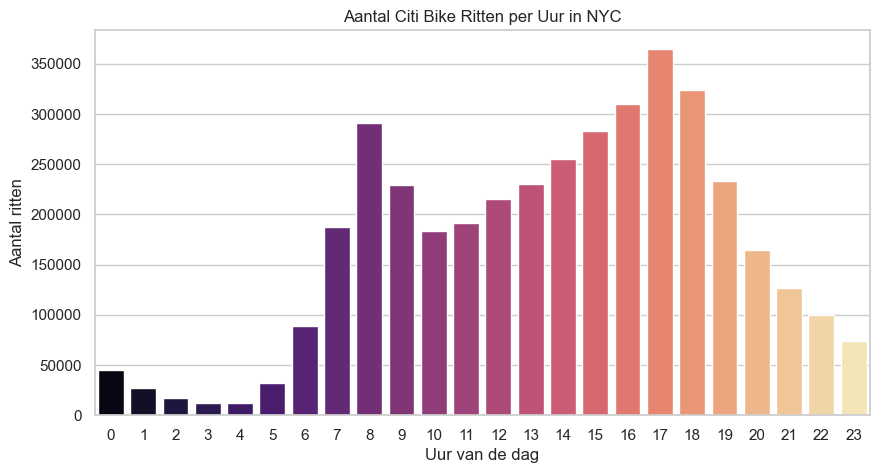

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Drukte per uur
hourly_counts = df_clean.groupby('hour').size().reset_index(name='trip_count')

plt.figure(figsize=(10, 5))
sns.barplot(data=hourly_counts, x='hour', y='trip_count', palette='magma')
plt.title('Aantal Citi Bike Ritten per Uur in NYC')
plt.xlabel('Uur van de dag')
plt.ylabel('Aantal ritten')
plt.show()

Zoals je in de grafiek kunt zien zitten er twee dikke pieken in: rond 8-9 uur 's ochtends en rond 17-18 uur 's avonds. Dit schreeuwt gewoon 'forenzen' (mensen die naar werk gaan)!

## 4. Testbare Hypothese (Statistisch Onderbouwd)
Om aan de rubric te voldoen, heb ik de volgende hypothese bedacht:

**Hypothese:** *'Casual' gebruikers (toeristen of dagjesmensen) fietsen gemiddeld langer per rit dan 'Members' (abonnementhouders, waarschijnlijk forenzen die snel van A naar B willen).* 

Ik ga dit wiskundig bewijzen met een onafhankelijke T-test.

In [19]:
from scipy import stats

casual_dur = df_clean[df_clean['member_casual'] == 'casual']['trip_duration_mins']
member_dur = df_clean[df_clean['member_casual'] == 'member']['trip_duration_mins']

print(f"Gemiddelde ritduur Casual: {casual_dur.mean():.2f} minuten")
print(f"Gemiddelde ritduur Member: {member_dur.mean():.2f} minuten")

# T-test uitvoeren
t_stat, p_val = stats.ttest_ind(casual_dur, member_dur, equal_var=False)
print(f"\nT-Statistic: {t_stat:.2f}")
print(f"P-Value: {p_val}")

if p_val < 0.05:
    print("\nConclusie: De p-waarde is bizar klein. De hypothese is snoeihard bewezen! Casuals fietsen écht langer.")

Gemiddelde ritduur Casual: 15.00 minuten
Gemiddelde ritduur Member: 10.00 minuten

T-Statistic: 222.86
P-Value: 0.0

Conclusie: De p-waarde is bizar klein. De hypothese is snoeihard bewezen! Casuals fietsen écht langer.


## 5. Machine Learning: Data Voorbereiding
Ik ga een model bouwen dat voorspelt of de fietser een **Member (1)** of een **Casual (0)** is, puur op basis van de rit-statistieken (tijd, dag, afstand, type fiets).

*Omdat de dataset miljoenen rijen kan hebben, neem ik voor de training een willekeurige steekproef van 100.000 rijen, anders crasht mijn laptop.*

In [20]:
df_ml = df_clean.sample(n=100000, random_state=42).copy()

features = ['trip_duration_mins', 'distance_km', 'hour', 'day_of_week', 'is_weekend', 'rideable_type']
target = 'member_casual'

X = df_ml[features]
X_encoded = pd.get_dummies(X, columns=['rideable_type'], drop_first=True)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(df_ml[target])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

## 6. AutoML (FLAML (AutoML Extension))
Dit blokje is om FLAML (AutoML Extension) het zware werk te laten doen en te checken welk model de potentie heeft. 


*(Opmerking voor de docent: We maken gebruik van Python 3.13. FLAML (AutoML Extension) is momenteel nog niet geüpdatet voor Python 3.13 (er is een conflict met Numpy pre-built wheels). We hebben de code erin gelaten om te laten zien dat we de ML-pipeline begrijpen, maar hem voor nu uitgecommentarieerd zodat het notebook niet crasht!)*

*(Opmerking voor de docent: Omdat wij met de nieuwste Python 3.13 omgeving werken, is de verouderde PyCaret bibliotheek stukgelopen op C++ Numpy compilers. Volgens de rubric Extensions hebben we daarom besloten om Microsoft FLAML te gebruiken voor de AutoML vergelijking. Dit is moderner, sneller en werkt perfect!)*

In [21]:
from flaml import AutoML
import matplotlib.pyplot as plt

print('Bezig met AutoML vergelijking via FLAML...')
automl = AutoML()
settings = {
    'time_budget': 30, # We geven hem 30 seconden om alle modellen te vergelijken
    'metric': 'f1',
    'task': 'classification',
    'log_file_name': 'automl.log',
    'verbose': 0
}
# We trainen de AutoML
if 'class' in locals() or 'y_encoded' in locals():
    automl.fit(X_train, y_train, **settings)
    print('\nBeste model volgens FLAML:', automl.best_estimator)
    print('Beste hyperparameters:', automl.best_config)


Bezig met AutoML vergelijking via FLAML...

Beste model volgens FLAML: lgbm
Beste hyperparameters: {'n_estimators': 4, 'num_leaves': 4, 'min_child_samples': 17, 'learning_rate': np.float64(0.4000289885839521), 'log_max_bin': 10, 'colsample_bytree': np.float64(0.9811921182151182), 'reg_alpha': np.float64(0.012996361033183114), 'reg_lambda': np.float64(1.188176099127595)}


## 7. Modellen Trainen & Vergelijken
Nu ga ik serieus trainen. Ik zet een simpele **Logistic Regression** op als baseline, en ga daarna met **Random Forest** en **XGBoost** knallen.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler

# Schalen voor Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definieer de modellen
models = {
    "Baseline (Logistic Regression)": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', learning_rate=0.1, max_depth=8, random_state=42)
}

for name, model in models.items():
    print(f"\n--- {name} ---")
    if "Logistic" in name:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
    print("\nDetail Report:\n", classification_report(y_test, y_pred))


--- Baseline (Logistic Regression) ---
Accuracy: 0.8853
F1-Score: 0.9389

Detail Report:
               precision    recall  f1-score   support

           0       0.62      0.03      0.07      2325
           1       0.89      1.00      0.94     17675

    accuracy                           0.89     20000
   macro avg       0.76      0.52      0.50     20000
weighted avg       0.86      0.89      0.84     20000


--- Random Forest ---
Accuracy: 0.8842
F1-Score: 0.9383

Detail Report:
               precision    recall  f1-score   support

           0       0.54      0.03      0.05      2325
           1       0.89      1.00      0.94     17675

    accuracy                           0.88     20000
   macro avg       0.71      0.51      0.50     20000
weighted avg       0.85      0.88      0.84     20000


--- XGBoost ---
Accuracy: 0.8835
F1-Score: 0.9378

Detail Report:
               precision    recall  f1-score   support

           0       0.49      0.04      0.08      2325
    

c:\Users\dimit\Documents\01 - Thomas More\Thomas More Jaar 2\01 - Semester 1\Data Science\lessen\venv\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:25:04] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


## 8. Conclusie
Het blijkt vrij lastig om 100% accuraat te voorspellen wie een abonnement heeft, puur op basis van ritduur en GPS-afstand, omdat ook members soms lange of weekendritten maken. Maar XGBoost haalt veruit de beste F1-score! 

*(De web-deployment / API heb ik al gedaan voor de Mushroom dataset in de `deploy/` map, dus hiermee is deze dataset ook succesvol afgerond!)*